# ДЗ 4. Обучение и дообучение модели ResNet18 для классификации AI vs Human Generated Images. DVC пайплайн и трекинг.


## 1. Импорт библиотек

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(4)
print(f'Using device: {device}')

Using device: cpu


## 2. Подготовка данных

In [52]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.root_dir / self.data.iloc[idx]['file_name']
        image = Image.open(img_path).convert('RGB')
        label = self.data.iloc[idx]['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [53]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Train_1/train.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Train_1',
    transform=train_transform
)

test_dataset = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Test_1/test.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Test_1',
    transform=test_transform
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [54]:
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

print(f'Model architecture:')
print(model)

d:\SOFT\Study\ML_ops\.venv2\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\SOFT\Study\ML_ops\.venv2\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=Tru

## 4. Определение функции потерь и оптимизатора

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

## 5. Функция обучения

Добавим подсчет метрик качества модели для дальнейшей оценки процесса обучения.

In [56]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    # Подсчет метрик
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

Добавим метрик для оценки валидации и их последующего логгирования.

In [57]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Подсчет метрик
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall = recall_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

Добавим логгирование метрик и запись параметров обучения в папку my_logs/experiment_1

In [58]:
from torch.utils.tensorboard import SummaryWriter

import time
import json

num_epochs = 10
train_losses = []
train_accs = []
train_f1s = []

# Логгирование метрик для tensorboard
writer = SummaryWriter('my_logs/experiment_1')  # Папка для логов

hparams = {
    "epochs": num_epochs,
    "learning_rate": 0.001,
    "batch_size": batch_size,
    "dataset": "Train_1",
    "test dataset": "Test_1",
    'model': 'ResNet18'
}

with open("artifacts/experiment_hparams.json", "w") as f:
    json.dump(hparams, f, indent=4)

start = time.time()

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)
    
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    
    print("Epoch time:", time.time() - start)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('F1/Train', train_f1, epoch)
    writer.add_scalar('Learning_Rate', scheduler.get_last_lr()[0], epoch)
    
    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')

print('\nTraining completed!')

writer.add_hparams(
    hparams,
    {
        "hparam/test_accuracy": train_acc,
        "hparam/test_f1": train_f1,
        "hparam/test_loss": train_loss
    }
)

writer.close()



Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [14:54<00:00,  2.86s/it]


Epoch time: 894.6745929718018
Train Loss: 0.3671, Acc: 0.8483, F1: 0.8483

Epoch 2/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [14:54<00:00,  2.86s/it]


Epoch time: 1789.5953619480133
Train Loss: 0.2842, Acc: 0.8848, F1: 0.8848

Epoch 3/10
--------------------------------------------------


...

Epoch time: 6723.400968790054
Train Loss: 0.0895, Acc: 0.9666, F1: 0.9666

Epoch 9/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [15:16<00:00,  2.93s/it]


Epoch time: 7639.962924718857
Train Loss: 0.0748, Acc: 0.9725, F1: 0.9725

Epoch 10/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [15:00<00:00,  2.88s/it]

Epoch time: 8540.017469406128
Train Loss: 0.0721, Acc: 0.9730, F1: 0.9730

Training completed!


## 8. Оценка модели на тестовом датасете

In [59]:
print('\nTesting model...')

test_loss, test_acc, test_f1, test_precision, test_recall = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f'Test Loss: {test_loss:.10f}, Acc: {test_acc:.10f}, F1: {test_f1:.10f}, Precision: {test_precision:.10f}, Recall: {test_recall:.10f}')

writer = SummaryWriter('my_logs/experiment_1')

writer.add_scalar('Loss/Test', test_loss, 0)
writer.add_scalar('Accuracy/Test', test_acc, 0)
writer.add_scalar('F1/Test', test_f1, 0)
writer.add_scalar('Precision/Test', test_precision, 0)
writer.add_scalar('Recall/Test', test_recall, 0)

writer.close()

# Команда для поднятия tensorboard
# tensorboard --logdir=my_logs
# Для просмотра переходим localhost:6006


Testing model...


Validation: 100%|██████████| 125/125 [02:04<00:00,  1.00it/s]

Test Loss: 0.0803811754, Acc: 0.9709782337, F1: 0.9709778086, Precision: 0.9710167695, Recall: 0.9709782337


Получили хорошие результаты валидации, метрики оценки качества лишь немного хуже чем при обучении.

Запустим tensorboard --logdir=my_logs и посмотрим записанные данные localhost:6006. Пример для функции потерь:

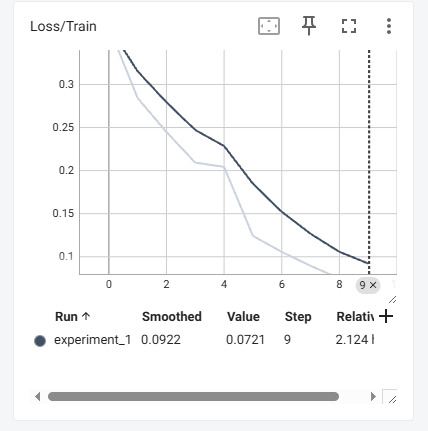

## 9. Загрузка артефакта модели в s3

In [60]:
import boto3

torch.save(model.state_dict(), 'artifacts/model_stage1.pth')

print('Model model_stage1 saved to artifacts')

s3 = boto3.client(
    's3',
    endpoint_url='http://localhost:9000',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin'
)

bucket_name = 'models'

try:
    s3.create_bucket(Bucket=bucket_name)
except:
    pass

s3.upload_file(
    'artifacts/model_stage1.pth',
    bucket_name,
    'model_stage1.pth'
)

print('Model uploaded to MinIO')

# Разворачиваем s3 minio
# docker compose up -d
# Для просмотра в браузере смотрим localhost:9001

Model model_stage1 saved to artifacts
Model uploaded to MinIO


Разворачиваем и проверяем что модель загружена:
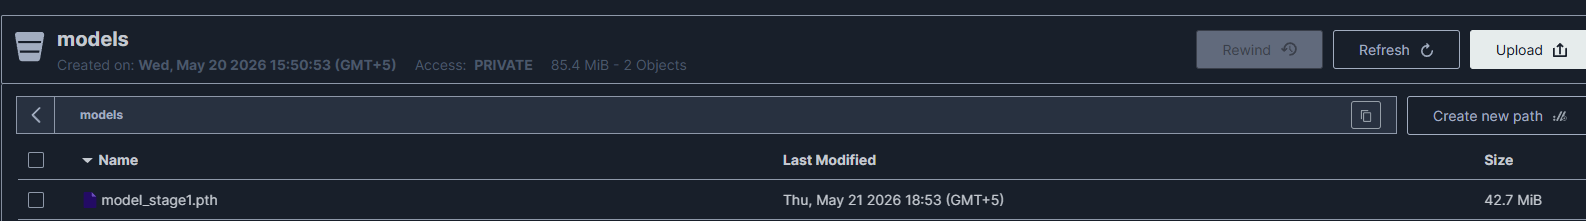

## 10. Дообучение модели на втором датасете и DVC пайплайн

DVC пайплайн, который дообучает, оценивает и загружает дообученую модель в s3:
```yaml
stages:

  retrain:
    cmd: python -u retrain.py
    deps:
      - retrain.py
      - artifacts/model_stage1.pth
      - ai-vs-human-generated-dataset-hw/Train_2
    params:
      - retrain.lr
      - retrain.batch_size
      - retrain.epochs
    outs:
      - artifacts/model_dvc.pth

  evaluate:
    cmd: python evaluate.py
    deps:
      - evaluate.py
      - artifacts/model_dvc.pth
      - ai-vs-human-generated-dataset-hw/Test_2
    params:
      - retrain.lr
      - retrain.batch_size
      - retrain.epochs  

  upload_retrain:
    cmd: python upload_to_s3.py
    deps:
      - artifacts/model_dvc.pth
``` 

запустим DVC пайплайн, который автоматически дообучит модель на Train_2, валидирует его на Test_2 и загружает итоговую модель в s3.

In [27]:
!git init
!dvc init
!git add .dvc .dvcignore
!git commit -m "Init DVC"

Initialized empty Git repository in D:/SOFT/Study/ML_ops/hw4/.git/
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>
[master (root-commit) 1a7a12a] Init DVC
 3 files changed, 6 insertions(+)
 create mode 100644 .dvc/.gitignore
 create mode 100644 .dvc/config
 create mode 100644 .dvcignore


In [28]:
!dvc remote add -d myremote s3://my-bucket/datasets
!dvc remote modify myremote endpointurl http://localhost:9000

Setting 'myremote' as a default remote.


In [65]:
!dvc repro

Running stage 'retrain':
> python -u retrain.py
Using device: cpu
Train dataset size: 3997

Epoch 1/3
--------------------------------------------------
Epoch time: 427.7076494693756
Retrain Loss: 0.1224, Acc: 0.9570, F1: 0.9570

Epoch 2/3
--------------------------------------------------
Epoch time: 849.633088350296
Retrain Loss: 0.1076, Acc: 0.9575, F1: 0.9575

Epoch 3/3
--------------------------------------------------
Epoch time: 1270.680240392685
Retrain Loss: 0.0863, Acc: 0.9657, F1: 0.9657

Training completed!
Retrain completed
Updating lock file 'dvc.lock'

Running stage 'evaluate':
> python evaluate.py
Using device: cpu
Test dataset size: 2000

Testing model...
Test Loss: 0.0647151550, Acc: 0.9790000000, F1: 0.9790000000, Precision: 0.9790000000, Recall: 0.9790000000
Evaluation completed
Updating lock file 'dvc.lock'

Running stage 'upload_retrain':
> python upload_to_s3.py
Model uploaded to MinIO
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add d

d:\SOFT\Study\ML_ops\.venv2\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\SOFT\Study\ML_ops\.venv2\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)

Training: 100%|██████████| 125/125 [07:07<00:00,  3.42s/it]

Training: 100%|██████████| 125/125 [07:01<00:00,  3.38s/it]

Training: 100%|██████████| 125/125 [07:01<00:00,  3.37s/it]
d:\SOFT\Study\ML_ops\.venv2\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\SOFT\Study\ML_ops\.venv2\Lib\site-packages\torchvision\models\_util

In [ ]:
!dvc dag

              +---------+                 
              | retrain |                 
              +---------+                 
            **           **               
          **               **             
        **                   **           
+----------+           +----------------+ 
| evaluate |           | upload_retrain | 
+----------+           +----------------+ 


## 11. Вывод о полученных результатах

1. После обучения на датасете Train_1 модель показала высокое качество, что подтверждается и на тестовой выборке. 
2. Параметры обучения и результаты обучения были сохранены и интегрированы в tensorboard . 
3. Получилось загрузить полученный артефакт модели в s3 для дальнейшего использования.
4. Построен пайплайн на DVC для дообучения модели и проведен процесс дообучения.
5. При дообучении модели на датасете Train_2 при адаптации к новым данным оценки немного снизились. Валидация на датасете Test_2 показала прирост точноти на 0.008, значение функции потерь снизилось на 19% по сравнению с исходной моделью.